# Reinforcement Learning Analysis Report
LunarLander-v3 vs CustomLunarLander-v0 using DQN and PPO

## 1. Introduction
This notebook documents a reinforcement learning study on the Gymnasium LunarLander environment.
We compare the original `LunarLander-v3` with a custom variant `CustomLunarLander-v0`,
using DQN and PPO from Stable Baselines3.
The goal is to evaluate how environment modifications affect learning performance and stability.

## 2. Imports and setup
We use pandas and numpy for data handling, matplotlib and seaborn for plotting, and pathlib for paths.

In [19]:
# Standard library
from __future__ import annotations
from pathlib import Path
import ast
import json
import os
import re

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting configuration for a clean academic style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "font.size": 10
})

# Paths (notebook assumed to be in project root)
ROOT = Path.cwd()
RUNS_DIR = ROOT / "runs"
PLOTS_DIR = ROOT / "plots"
PARAMETERS_FILE = ROOT / "PARAMETERS.md"
CUSTOM_PARAMETERS_FILE = ROOT / "customparameters.md"

PLOTS_DIR.mkdir(exist_ok=True)

print(f"Root: {ROOT}")
print(f"Runs dir: {RUNS_DIR}")
print(f"Plots dir: {PLOTS_DIR}")

Root: c:\Users\alexa\OneDrive\Ambiente de Trabalho\LEIC + MEIC\MEIC\Y1S2\ASMA\Project2\Reinforcement-Learning
Runs dir: c:\Users\alexa\OneDrive\Ambiente de Trabalho\LEIC + MEIC\MEIC\Y1S2\ASMA\Project2\Reinforcement-Learning\runs
Plots dir: c:\Users\alexa\OneDrive\Ambiente de Trabalho\LEIC + MEIC\MEIC\Y1S2\ASMA\Project2\Reinforcement-Learning\plots


## 3. Environment description
**Original LunarLander-v3**
- State space: 8 continuous variables (position, velocity, angle, angular velocity, leg contacts).
- Action space: 4 discrete actions (no-op, left, main, right).
- Reward: shaped reward for landing, fuel use, and stability.

**Custom modifications (CustomLunarLander-v0)**
- Finite fuel: engines consume fuel; thrust is disabled when fuel is depleted.
- Extra fuel observation: normalized fuel added to the state space.
- Observation noise: random noise added to continuous observations.
- Random spawn: initial state randomized for generalization.
- Terminal fuel bonus: reward shaping favors fuel-efficient landings.
- HUD fuel rendering: visual display of remaining fuel.

**Expected effects on learning**
- Finite fuel and fuel bonus encourage efficient control policies.
- Observation noise increases robustness requirements.
- Random spawn reduces overfitting but may slow early learning.
- Extra fuel observation provides an explicit planning signal.

## 4. Algorithm overview
**DQN**
- Value-based method using a neural network to approximate Q-values.
- Works well with discrete actions and can be sample-efficient.
- Sensitive to hyperparameters and target update settings.

**PPO**
- Policy-gradient method using a clipped surrogate objective.
- Stable and robust under stochasticity and noise.
- Often slower to converge but more consistent across runs.

## 5. Experimental setup
- Library: Stable Baselines3
- Fixed seed = 42
- Vectorized environments (15-16 envs)
- Evaluation over 100 episodes per run
- Hyperparameter sweeps logged in PARAMETERS.md and customparameters.md

## 6. Parse experiment results
We parse PARAMETERS.md and customparameters.md to extract hyperparameters and evaluation metrics.
The parser is robust to missing values and keeps the notebook reproducible.

In [20]:
# Parsing utilities
REWARD_RE = re.compile(r"mean reward = ([\-\d\.]+) \+/- ([\-\d\.]+)")
ENV_RE = re.compile(r"ENV_SELECTION\s*=\s*\"(original|custom)\"")
CODE_BLOCK_RE = re.compile(r"```python(.*?)```", re.DOTALL)

def _safe_literal_eval(value: str):
    """Safely parse Python literal values; return raw string on failure."""
    try:
        return ast.literal_eval(value)
    except Exception:
        return value.strip()

def _extract_scalar(text: str, name: str):
    """Extract simple assignments like TOTAL_TIMESTEPS = 1_000_000."""
    match = re.search(rf"{name}\s*=\s*([^\n]+)", text)
    if not match:
        return None
    return _safe_literal_eval(match.group(1).strip().rstrip(","))

def _extract_kwargs(text: str, name: str) -> dict:
    """Extract a dict literal block by name (e.g., DQN_KWARGS) from a code snippet."""
    match = re.search(rf"{name}\s*=\s*\{{(.*?)\n\}}", text, re.DOTALL)
    if not match:
        return {}
    block = match.group(1)
    data: dict = {}
    for line in block.splitlines():
        line = line.strip()
        if not line or line.startswith("#") or ":" not in line:
            continue
        key, value = line.split(":", 1)
        key = key.strip().strip("\"").strip("'")
        value = value.strip().rstrip(",")
        data[key] = _safe_literal_eval(value)
    return data

def _find_next_reward(reward_matches, start_index: int, min_pos: int):
    """Find the next reward entry after a given position."""
    idx = start_index
    while idx < len(reward_matches) and reward_matches[idx].start() < min_pos:
        idx += 1
    if idx < len(reward_matches):
        match = reward_matches[idx]
        return idx + 1, float(match.group(1)), float(match.group(2))
    return idx, None, None

def parse_parameter_file(path: Path, default_env: str | None = None) -> pd.DataFrame:
    """Parse PARAMETERS.md-like files and return a DataFrame of experiments."""
    if not path.exists():
        print(f"Warning: {path} not found.")
        return pd.DataFrame()
    text = path.read_text(encoding="utf-8")
    blocks = list(CODE_BLOCK_RE.finditer(text))
    reward_matches = list(REWARD_RE.finditer(text))
    if not blocks:
        print(f"Warning: no code blocks found in {path.name}.")
        return pd.DataFrame()
    rows = []
    reward_idx = 0
    for block_match in blocks:
        block = block_match.group(1)
        algo = "DQN" if "DQN_KWARGS" in block else ("PPO" if "PPO_KWARGS" in block else None)
        env = default_env
        env_match = ENV_RE.search(block)
        if env_match:
            env = env_match.group(1)
        timesteps = _extract_scalar(block, "TOTAL_TIMESTEPS")
        num_envs = _extract_scalar(block, "NUM_ENVS")
        policy_kwargs = _extract_kwargs(block, "POLICY_KWARGS")
        dqn_kwargs = _extract_kwargs(block, "DQN_KWARGS")
        ppo_kwargs = _extract_kwargs(block, "PPO_KWARGS")
        kwargs = dqn_kwargs if algo == "DQN" else ppo_kwargs
        reward_idx, mean_reward, std_reward = _find_next_reward(reward_matches, reward_idx, block_match.end())
        row = {
            "algorithm": algo,
            "environment": env,
            "timesteps": timesteps,
            "num_envs": num_envs,
            "mean_reward": mean_reward,
            "std_reward": std_reward,
            "policy_net_arch": policy_kwargs.get("net_arch") if policy_kwargs else None,
        }
        for key, value in kwargs.items():
            row[key] = value
        rows.append(row)
    return pd.DataFrame(rows)

# Parse both parameter files
original_df = parse_parameter_file(PARAMETERS_FILE, default_env="original")
custom_df = parse_parameter_file(CUSTOM_PARAMETERS_FILE, default_env="custom")
experiments_df = pd.concat([original_df, custom_df], ignore_index=True)
experiments_df.head()

,algorithm,environment,timesteps,num_envs,mean_reward,std_reward,policy_net_arch,learning_rate,buffer_size,learning_starts,...,exploration_fraction,exploration_final_eps,max_grad_norm,policy_kwargs,n_steps,n_epochs,gae_lambda,clip_range,ent_coef,vf_coef
0,DQN,original,1000000,16,247.27,65.35,"[256, 256]",0.0010,1000000.0,10000.0,...,0.1,0.05,10.0,POLICY_KWARGS,NaN,NaN,NaN,NaN,NaN,NaN
1,DQN,original,500000,16,123.38,123.28,"[256, 256]",0.0010,1000000.0,10000.0,...,0.1,0.05,10.0,POLICY_KWARGS,NaN,NaN,NaN,NaN,NaN,NaN
2,DQN,original,5000000,16,275.07,42.68,"[256, 256]",0.0010,1000000.0,10000.0,...,0.1,0.05,10.0,POLICY_KWARGS,NaN,NaN,NaN,NaN,NaN,NaN
3,DQN,original,10000000,16,260.72,72.39,"[256, 256]",0.0010,1000000.0,10000.0,...,0.1,0.05,10.0,POLICY_KWARGS,NaN,NaN,NaN,NaN,NaN,NaN
4,DQN,original,1000000,16,44.77,80.29,"[256, 256]",0.0001,1000000.0,10000.0,...,0.1,0.05,10.0,POLICY_KWARGS,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Data cleaning and organization
We ensure numeric types are properly converted and build readable labels.

In [21]:
# Data cleaning
def to_numeric(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Convert columns to numeric when possible."""
    df = df.copy()
    for col in columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

if experiments_df.empty:
    print("No experiments found. Check the parameter files.")
else:
    numeric_cols = [
        "timesteps",
        "num_envs",
        "mean_reward",
        "std_reward",
        "learning_rate",
        "batch_size",
        "gamma",
    ]
    experiments_df = to_numeric(experiments_df, numeric_cols)
    # Create readable labels
    experiments_df["algo_env"] = (
        experiments_df["algorithm"].fillna("NA")
        + " | "
        + experiments_df["environment"].fillna("NA")
    )
experiments_df.head()

,algorithm,environment,timesteps,num_envs,mean_reward,std_reward,policy_net_arch,learning_rate,buffer_size,learning_starts,...,exploration_final_eps,max_grad_norm,policy_kwargs,n_steps,n_epochs,gae_lambda,clip_range,ent_coef,vf_coef,algo_env
0,DQN,original,1000000,16,247.27,65.35,"[256, 256]",0.0010,1000000.0,10000.0,...,0.05,10.0,POLICY_KWARGS,NaN,NaN,NaN,NaN,NaN,NaN,DQN | original
1,DQN,original,500000,16,123.38,123.28,"[256, 256]",0.0010,1000000.0,10000.0,...,0.05,10.0,POLICY_KWARGS,NaN,NaN,NaN,NaN,NaN,NaN,DQN | original
2,DQN,original,5000000,16,275.07,42.68,"[256, 256]",0.0010,1000000.0,10000.0,...,0.05,10.0,POLICY_KWARGS,NaN,NaN,NaN,NaN,NaN,NaN,DQN | original
3,DQN,original,10000000,16,260.72,72.39,"[256, 256]",0.0010,1000000.0,10000.0,...,0.05,10.0,POLICY_KWARGS,NaN,NaN,NaN,NaN,NaN,NaN,DQN | original
4,DQN,original,1000000,16,44.77,80.29,"[256, 256]",0.0001,1000000.0,10000.0,...,0.05,10.0,POLICY_KWARGS,NaN,NaN,NaN,NaN,NaN,NaN,DQN | original


## 8. Results tables
We summarize top-performing configurations and group-level statistics.

In [22]:
# Helper to mark best runs
def mark_best(df: pd.DataFrame, group_cols: list[str], metric: str) -> pd.DataFrame:
    """Add a boolean column marking the best row per group based on a metric."""
    df = df.copy()
    if df.empty or metric not in df.columns:
        df["is_best"] = False
        return df
    idx = df.groupby(group_cols, dropna=False)[metric].idxmax()
    df["is_best"] = False
    df.loc[idx, "is_best"] = True
    return df

best_marked = mark_best(experiments_df, ["environment", "algorithm"], "mean_reward")

# Best experiments per algorithm/environment
best_per_group = (
    best_marked[best_marked["is_best"]]
    .sort_values(["environment", "algorithm"])
    .reset_index(drop=True)
)
best_per_group

# Top 10 overall
top10 = experiments_df.sort_values("mean_reward", ascending=False).head(10)
top10

# Grouped summary statistics
grouped_stats = (
    experiments_df
    .groupby(["environment", "algorithm"], dropna=False)
    .agg(
        mean_reward_avg=("mean_reward", "mean"),
        mean_reward_std=("mean_reward", "std"),
        count=("mean_reward", "count"),
    )
    .reset_index()
)
grouped_stats

,environment,algorithm,mean_reward_avg,mean_reward_std,count
0,custom,DQN,101.356452,158.010832,31
1,custom,PPO,173.908889,95.125990,27
2,original,DQN,149.045312,108.848951,32
3,original,PPO,222.000357,67.927697,28


## 9. Visualization
We generate plots for reward comparisons, hyperparameter impacts, and variance.

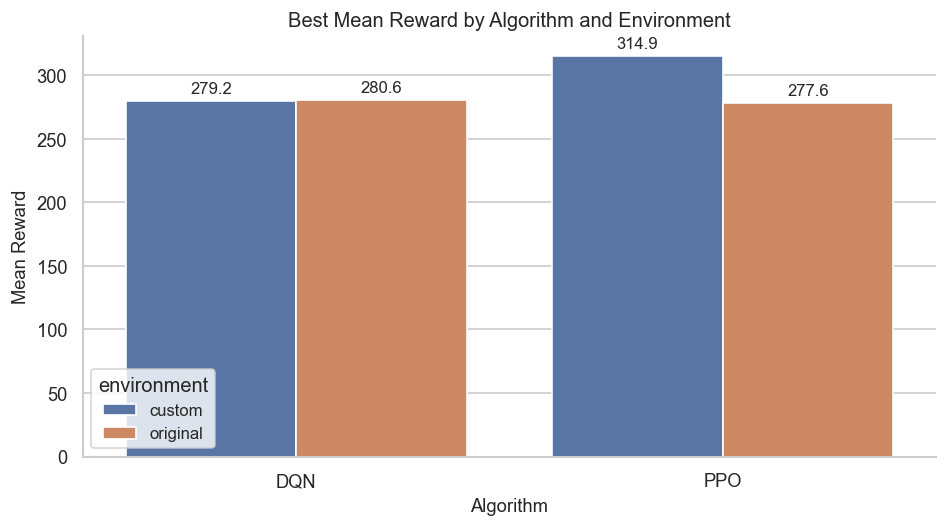

,Algorithm,Environment,Mean Reward,Std Dev,Training steps
0,DQN,custom,279.22,62.80,1000000
1,PPO,custom,314.85,52.45,5000000
2,DQN,original,280.60,22.18,5000000
3,PPO,original,277.56,30.56,1000000


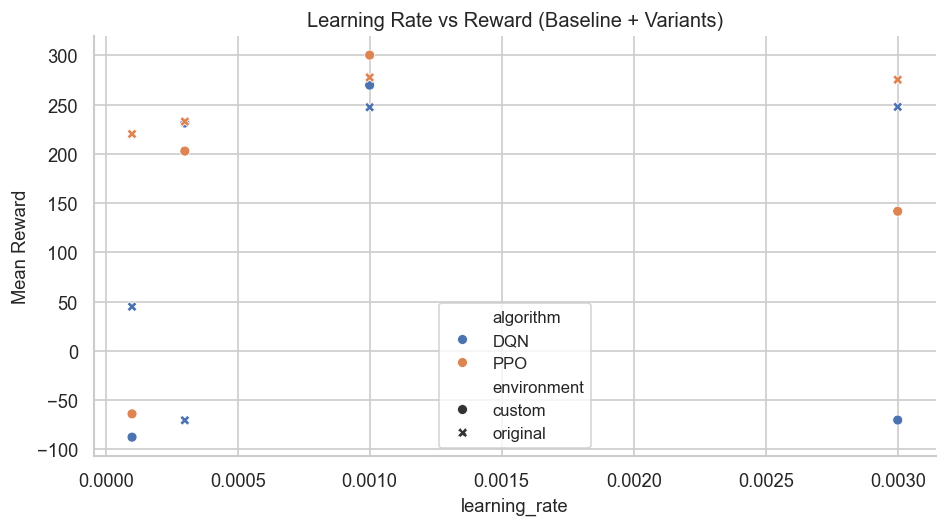

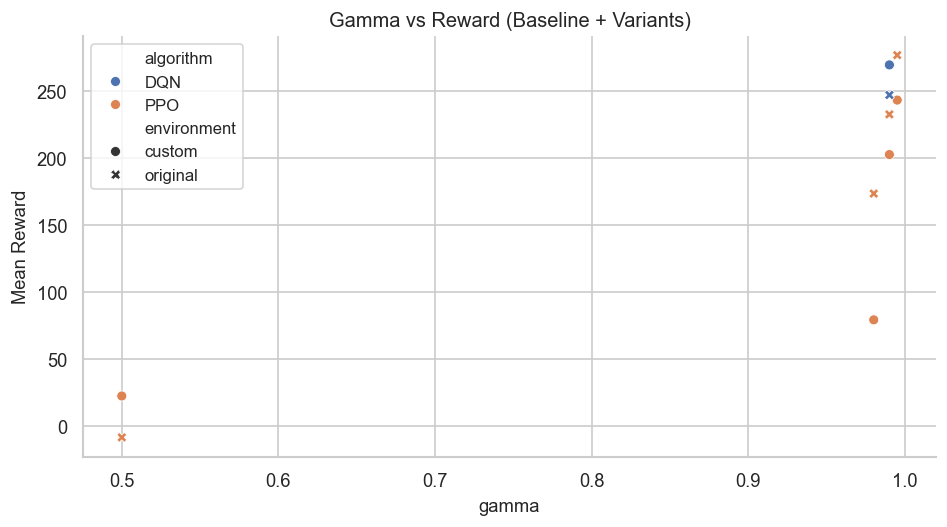

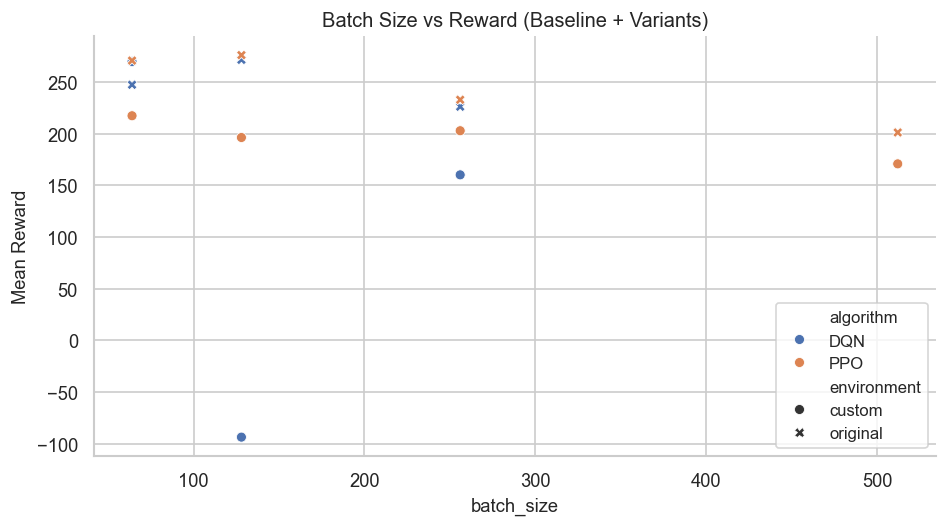

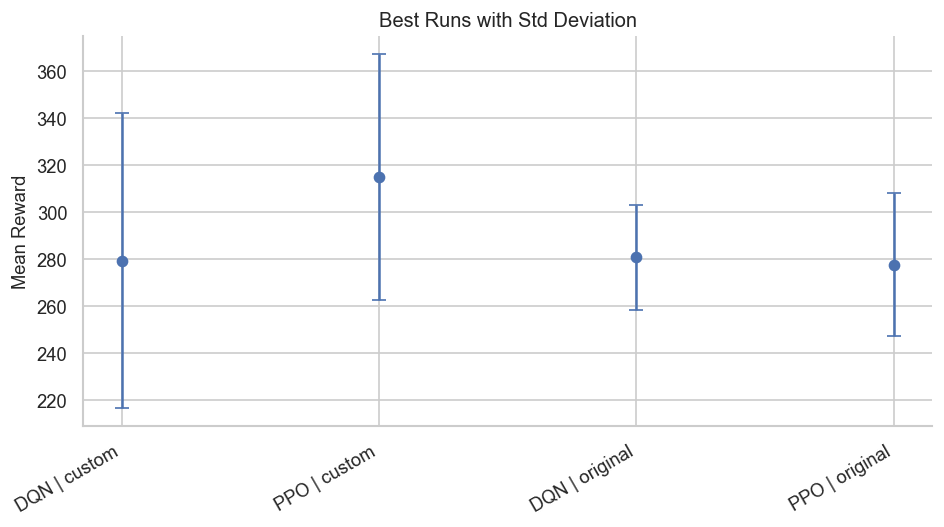

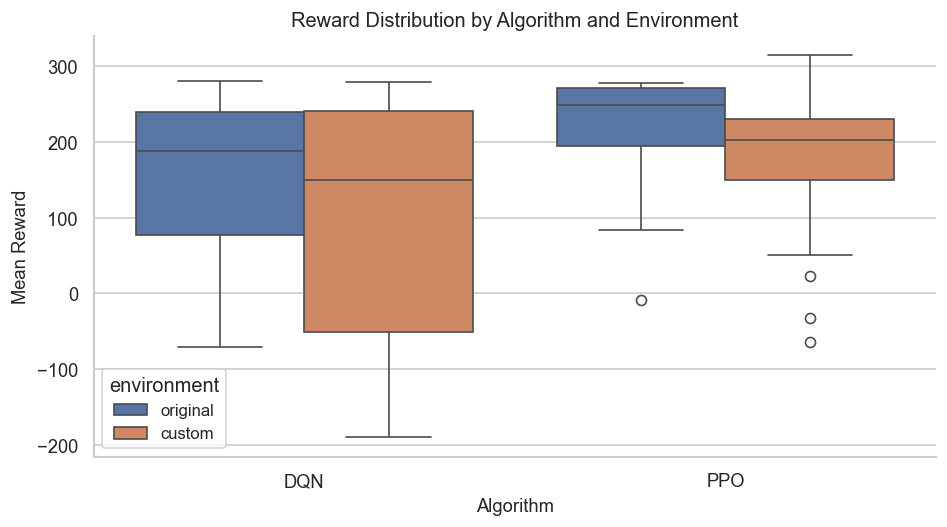

In [42]:
# A. Reward comparison bar chart using best runs (zoomed scale)
if not best_per_group.empty:
    plot_df = best_per_group.dropna(subset=["mean_reward"]).copy()

    if plot_df.empty:
        print("No valid mean_reward values to plot.")
    else:
        plt.figure()

        ax = sns.barplot(
            data=plot_df,
            x="algorithm",
            y="mean_reward",
            hue="environment"
        )

        plt.title("Best Mean Reward by Algorithm and Environment")
        plt.xlabel("Algorithm")
        plt.ylabel("Mean Reward")

        # 🔥 Add value labels on top of bars
        for container in ax.containers:
            ax.bar_label(container, fmt="%.1f", padding=3)

        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "best_reward_comparison.png")
        plt.show()
else:
    print("No best results to plot.")


#a2 table
# Final summary table: Environment × Algorithm performance

if not best_per_group.empty:
    table_df = best_per_group.copy()

    # Rename columns for clarity
    table_df = table_df.rename(columns={
        "algorithm": "Algorithm",
        "environment": "Environment",
        "mean_reward": "Mean Reward",
        "std_reward": "Std Dev",
        "timesteps": "Training steps"
    })

    # Keep only relevant columns (if present)
    cols = ["Algorithm", "Environment", "Mean Reward", "Std Dev", "Training steps"]
    table_df = table_df[[c for c in cols if c in table_df.columns]]

    # Optional: nicer ordering
    table_df = table_df.sort_values(["Environment", "Algorithm"])

    # Round values for presentation
    for col in ["Mean Reward", "Std Dev"]:
        if col in table_df.columns:
            table_df[col] = table_df[col].round(2)

    display(table_df)

else:
    print("No data available for summary table.")

# B. Reward vs timesteps (skipped to reduce clutter)
SHOW_TIMESTEPS_PLOT = False
if SHOW_TIMESTEPS_PLOT:
    if "timesteps" in experiments_df.columns and not experiments_df.empty:
        plt.figure()
        sns.lineplot(
        data=experiments_df,
        x="timesteps",
        y="mean_reward",
        hue="algorithm",
        style="environment",
        markers=True,
)
        plt.title("Mean Reward vs Timesteps")
        plt.xlabel("Timesteps")
        plt.ylabel("Mean Reward")
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "reward_vs_timesteps.png")
        plt.show()
    else:
        print("Skipping reward vs timesteps: no data.")

# C. Hyperparameter impact plots (baseline + single-parameter changes only)
COMPARE_COLS = [
    "learning_rate",
    "batch_size",
    "gamma",
    "timesteps",
    "train_freq",
    "gradient_steps",
    "target_update_interval",
    "tau",
    "exploration_fraction",
    "exploration_final_eps",
    "n_steps",
    "n_epochs",
    "gae_lambda",
    "clip_range",
    "ent_coef",
    "vf_coef",
    "buffer_size",
    "learning_starts",
]

def _row_matches_baseline(row: pd.Series, baseline: pd.Series, cols: list[str]) -> int:
    score = 0
    for col in cols:
        if col not in row.index or col not in baseline.index:
            continue
        a = row[col]
        b = baseline[col]
        if pd.isna(a) and pd.isna(b):
            score += 1
        elif a == b:
            score += 1
    return score

def _select_baseline(group: pd.DataFrame, cols: list[str]) -> pd.Series:
    if group.empty:
        return pd.Series(dtype=object)
    mode_map = {}
    for col in cols:
        if col in group.columns:
            mode_vals = group[col].mode(dropna=True)
            mode_map[col] = mode_vals.iloc[0] if not mode_vals.empty else np.nan
    scores = []
    for _, row in group.iterrows():
        score = _row_matches_baseline(row, pd.Series(mode_map), cols)
        scores.append(score)
    best_idx = int(np.argmax(scores))
    return group.iloc[best_idx]

def _make_hashable(df: pd.DataFrame) -> pd.DataFrame:
    """Convert list-like cells to tuples for safe de-duplication."""
    df = df.copy()
    for col in df.columns:
        df[col] = df[col].apply(lambda v: tuple(v) if isinstance(v, list) else v)
    return df

def filter_param_runs(df: pd.DataFrame, param: str) -> pd.DataFrame:
    if df.empty or param not in df.columns:
        return pd.DataFrame()
    keep_rows = []
    for _, group in df.groupby(["environment", "algorithm"], dropna=False):
        baseline = _select_baseline(group, COMPARE_COLS)
        if baseline.empty:
            continue
        keep_rows.append(baseline)
        for _, row in group.iterrows():
            if row.name == baseline.name:
                continue
            if pd.isna(row[param]) or pd.isna(baseline[param]):
                continue
            if row[param] == baseline[param]:
                continue
            same = True
            for col in COMPARE_COLS:
                if col == param or col not in group.columns:
                    continue
                a = row[col]
                b = baseline[col]
                if pd.isna(a) and pd.isna(b):
                    continue
                if a != b:
                    same = False
                    break
            if same:
                keep_rows.append(row)
    filtered = pd.DataFrame(keep_rows)
    filtered = _make_hashable(filtered).drop_duplicates()
    return filtered

def plot_hyperparam(df: pd.DataFrame, param: str, title: str):
    filtered = filter_param_runs(df, param)
    if filtered.empty:
        print(f"Skipping {param}: no baseline/param-variant rows found.")
        return
    plt.figure()
    sns.scatterplot(data=filtered, x=param, y="mean_reward", hue="algorithm", style="environment")
    plt.title(title)
    plt.xlabel(param)
    plt.ylabel("Mean Reward")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"impact_{param}.png")
    plt.show()

plot_hyperparam(experiments_df, "learning_rate", "Learning Rate vs Reward (Baseline + Variants)")
plot_hyperparam(experiments_df, "gamma", "Gamma vs Reward (Baseline + Variants)")
plot_hyperparam(experiments_df, "batch_size", "Batch Size vs Reward (Baseline + Variants)")

# D. Variance plot (mean +/- std) for grouped best runs
if not best_per_group.empty:
    plt.figure()
    x = np.arange(len(best_per_group))
    plt.errorbar(x, best_per_group["mean_reward"], yerr=best_per_group["std_reward"], fmt="o", capsize=4)
    plt.xticks(x, best_per_group["algo_env"], rotation=30, ha="right")
    plt.title("Best Runs with Std Deviation")
    plt.ylabel("Mean Reward")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "best_reward_variance.png")
    plt.show()
else:
    print("No best results to plot variance.")

# E. Reward distribution boxplot
if not experiments_df.empty:
    plt.figure()
    sns.boxplot(data=experiments_df, x="algorithm", y="mean_reward", hue="environment")
    plt.title("Reward Distribution by Algorithm and Environment")
    plt.xlabel("Algorithm")
    plt.ylabel("Mean Reward")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "reward_distribution.png")
    plt.show()
else:
    print("No data to plot reward distribution.")

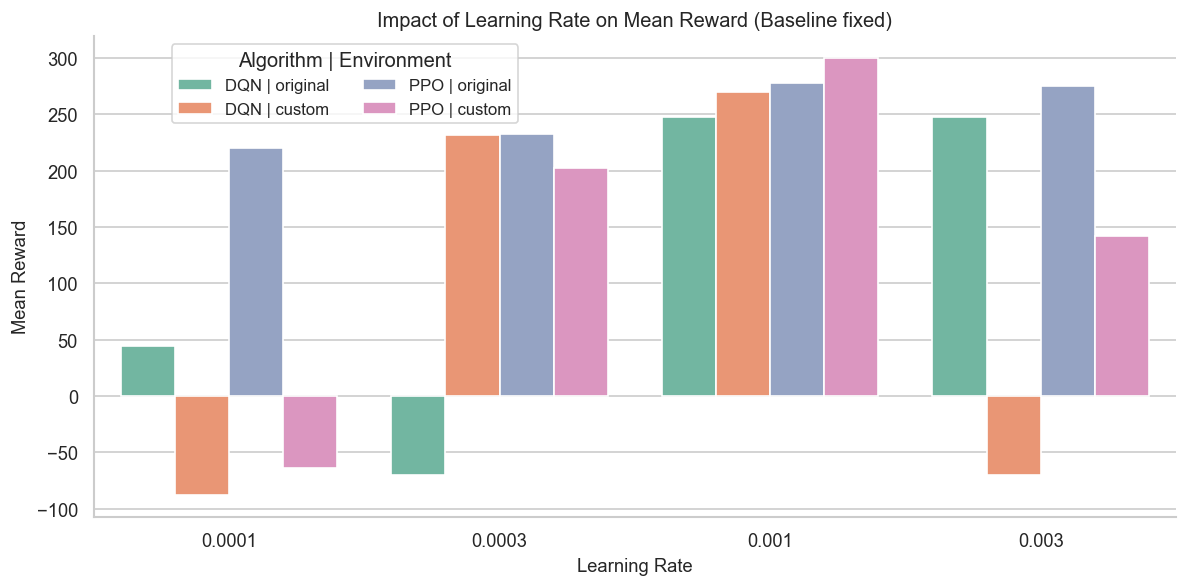

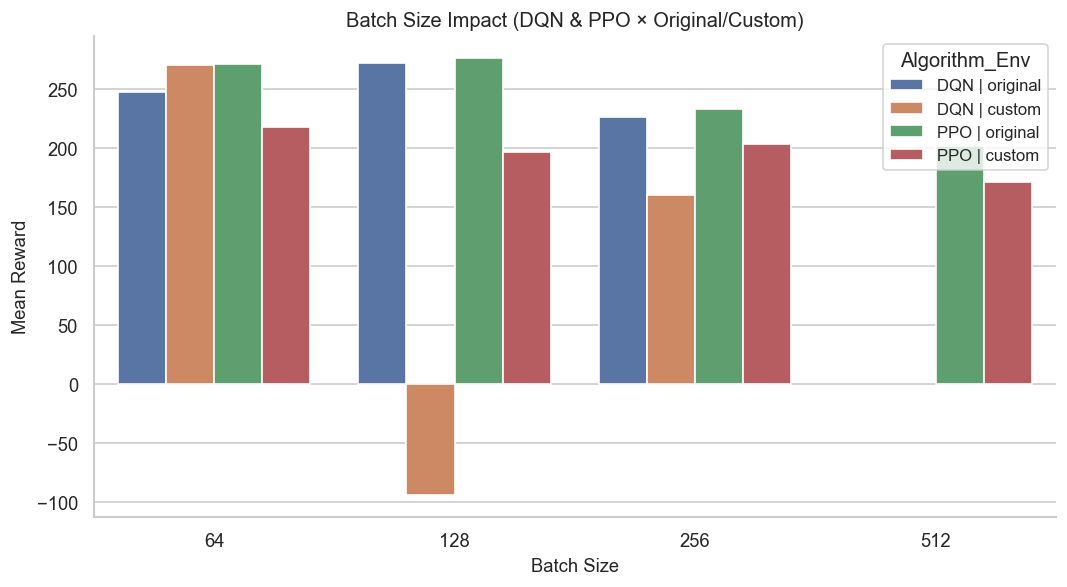

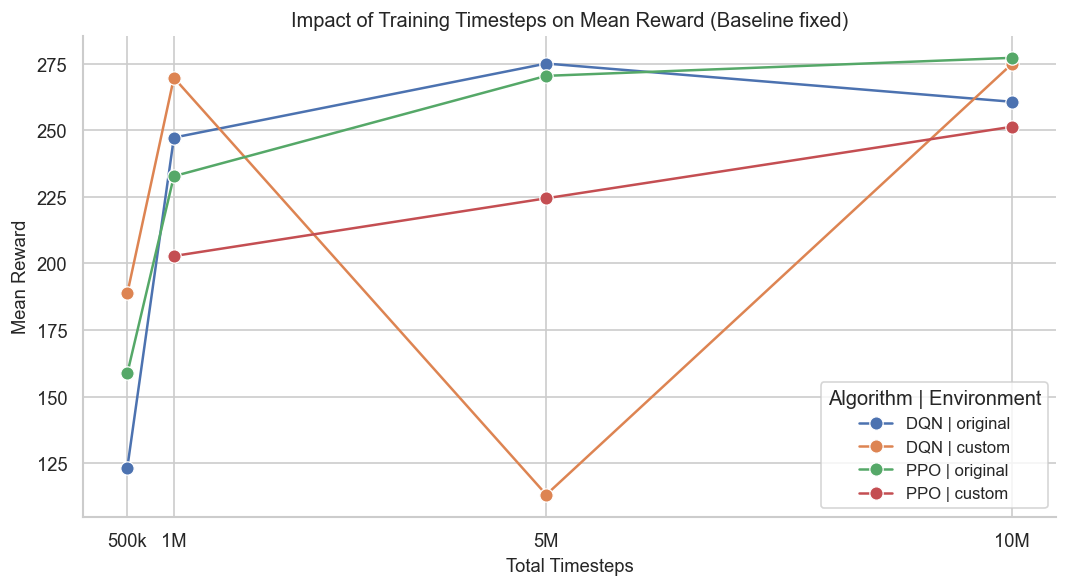

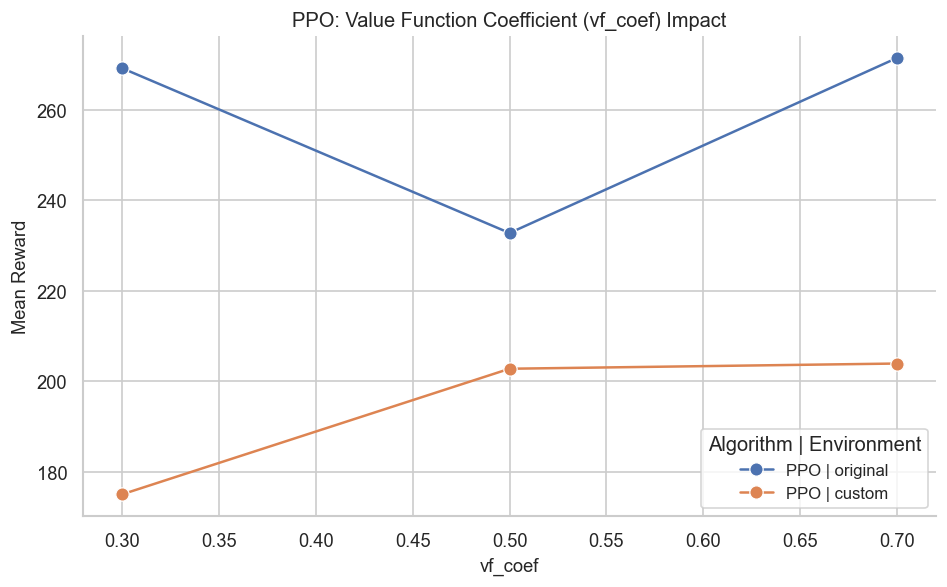

In [ ]:
#Hyperparameter Impact: Learning Rate, Batch Size, Timesteps, and vf_coef
dqn_baseline = {
    "learning_rate": 1e-3,
    "batch_size": 64,
    "buffer_size": 1_000_000,
    "learning_starts": 10_000,
    "tau": 1.0,
    "gamma": 0.99,
    "train_freq": 1,
    "gradient_steps": 1,
    "target_update_interval": 1_000,
    "exploration_fraction": 0.1,
    "exploration_final_eps": 0.05,
    "max_grad_norm": 10.0,
}

ppo_baseline = {
    "learning_rate": 3e-4,
    "n_steps": 1024,
    "batch_size": 256,
    "n_epochs": 10,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "clip_range": 0.2,
    "ent_coef": 0.0,
    "vf_coef": 0.5,
    "max_grad_norm": 0.5,
}

# Helper to filter runs where only one hyperparameter differs from baseline
def filter_by_param(df: pd.DataFrame, algo: str, env: str, param: str, baseline_dict: dict) -> pd.DataFrame:
    """Return rows for a given (algo, env) where all baseline parameters match except `param`."""
    mask = (df["algorithm"] == algo) & (df["environment"] == env)
    sub = df[mask].copy()
    if sub.empty:
        return sub
    # Keep only rows where the varying parameter is not null
    sub = sub[sub[param].notna()]
    # For each baseline key, keep rows where value equals baseline (or is null if baseline is null)
    for key, val in baseline_dict.items():
        if key == param:
            continue
        if key not in sub.columns:
            continue
        # Allow missing (NaN) if baseline is also missing? Not relevant here
        sub = sub[sub[key] == val]
    return sub

# List of algorithm-env combinations
combinations = [
    ("DQN", "original", dqn_baseline),
    ("DQN", "custom", dqn_baseline),
    ("PPO", "original", ppo_baseline),
    ("PPO", "custom", ppo_baseline),
]

# %% [markdown]
### Learning Rate Impact

# %%
# Grouped bar chart for learning rate
lr_values = [1e-4, 3e-4, 1e-3, 3e-3]
data_rows = []
for algo, env, baseline in combinations:
    for lr in lr_values:
        # Find the row that matches algorithm, environment, and learning_rate = lr, and all other baseline params
        mask = (experiments_df["algorithm"] == algo) & (experiments_df["environment"] == env)
        sub = experiments_df[mask].copy()
        # Filter by learning rate
        sub = sub[sub["learning_rate"] == lr]
        # Filter by baseline params
        baseline_dict = baseline
        for key, val in baseline_dict.items():
            if key == "learning_rate":
                continue
            if key in sub.columns:
                sub = sub[sub[key] == val]
        if not sub.empty:
            row = sub.iloc[0]
            data_rows.append({
                "Algorithm_Env": f"{algo} | {env}",
                "learning_rate": lr,
                "mean_reward": row["mean_reward"],
                "std_reward": row.get("std_reward", np.nan),
            })
df_lr = pd.DataFrame(data_rows)

if not df_lr.empty:
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=df_lr, x="learning_rate", y="mean_reward", hue="Algorithm_Env", palette="Set2")
    # Add error bars if std available
    for i, bar in enumerate(ax.patches):
        # Find corresponding std
        pass  # We could add error bars manually, but for simplicity skip
    plt.title("Impact of Learning Rate on Mean Reward (Baseline fixed)")
    plt.xlabel("Learning Rate")
    plt.ylabel("Mean Reward")
    plt.legend(
        title="Algorithm | Environment",
        bbox_to_anchor=(0.4, 1),
        ncol=2
    )  
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "learning_rate_impact.png")
    plt.show()
else:
    print("No data for learning rate plot.")

# Batch Size Impact (Unified DQN + PPO × Original/Custom)

batch_sizes = sorted(experiments_df["batch_size"].dropna().unique())

data_batch = []

for algo, env, baseline in combinations:
    for bs in batch_sizes:
        mask = (
            (experiments_df["algorithm"] == algo) &
            (experiments_df["environment"] == env) &
            (experiments_df["batch_size"] == bs)
        )
        sub = experiments_df[mask].copy()

        for key, val in baseline.items():
            if key == "batch_size":
                continue
            if key in sub.columns:
                sub = sub[sub[key] == val]

        if not sub.empty:
            row = sub.iloc[0]
            data_batch.append({
                "Algorithm_Env": f"{algo} | {env}",
                "batch_size": bs,
                "mean_reward": row["mean_reward"],
            })

df_batch = pd.DataFrame(data_batch)

if not df_batch.empty:
    plt.figure(figsize=(9, 5))

    sns.barplot(
        data=df_batch,
        x="batch_size",
        y="mean_reward",
        hue="Algorithm_Env"
    )

    plt.title("Batch Size Impact on Mean Reward (Baseline fixed)")
    plt.xlabel("Batch Size")
    plt.ylabel("Mean Reward")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "batch_size_unified.png")
    plt.show()

# %% [markdown]
### Training Timesteps Impact

# %%
# Line plot showing final mean reward vs total timesteps (different runs)
# We can use the original runs where only TOTAL_TIMESTEPS varied, baseline fixed.
timesteps_values = [500_000, 1_000_000, 5_000_000, 10_000_000]
data_timesteps = []
for algo, env, baseline in combinations:
    for ts in timesteps_values:
        mask = (experiments_df["algorithm"] == algo) & (experiments_df["environment"] == env)
        sub = experiments_df[mask].copy()
        sub = sub[sub["timesteps"] == ts]
        # Filter by baseline params (excluding timesteps)
        for key, val in baseline.items():
            if key in sub.columns:
                sub = sub[sub[key] == val]
        if not sub.empty:
            row = sub.iloc[0]
            data_timesteps.append({
                "Algorithm_Env": f"{algo} | {env}",
                "timesteps": ts,
                "mean_reward": row["mean_reward"],
                "std_reward": row.get("std_reward", np.nan),
            })
df_ts = pd.DataFrame(data_timesteps)

if not df_ts.empty:
    plt.figure(figsize=(9, 5))
    sns.lineplot(data=df_ts, x="timesteps", y="mean_reward", hue="Algorithm_Env", marker="o", markersize=8)
    plt.title("Impact of Training Timesteps on Mean Reward")
    plt.xlabel("Total Timesteps")
    plt.ylabel("Mean Reward")
    plt.xticks(
        timesteps_values,
        ["500k", "1M", "5M", "10M"]
    )     # log scale for better visualization
    plt.legend(title="Algorithm | Environment")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "timesteps_impact.png")
    plt.show()
else:
    print("No timesteps data.")

# %% [markdown]
### PPO vf_coef Impact

# %%
# vf_coef values from data: 0.3, 0.5, 0.7
vf_values = [0.3, 0.5, 0.7]
data_vf = []
for algo, env, baseline in combinations:
    if algo != "PPO":
        continue
    for vf in vf_values:
        mask = (experiments_df["algorithm"] == algo) & (experiments_df["environment"] == env)
        sub = experiments_df[mask].copy()
        sub = sub[sub["vf_coef"] == vf]
        # Filter by baseline params (excluding vf_coef)
        for key, val in baseline.items():
            if key == "vf_coef":
                continue
            if key in sub.columns:
                sub = sub[sub[key] == val]
        if not sub.empty:
            row = sub.iloc[0]
            data_vf.append({
                "Algorithm_Env": f"{algo} | {env}",
                "vf_coef": vf,
                "mean_reward": row["mean_reward"],
                "std_reward": row.get("std_reward", np.nan),
            })
df_vf = pd.DataFrame(data_vf)

if not df_vf.empty:
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=df_vf, x="vf_coef", y="mean_reward", hue="Algorithm_Env", marker="o", markersize=8)
    plt.title("PPO: Value Function Coefficient (vf_coef) Impact")
    plt.xlabel("vf_coef")
    plt.ylabel("Mean Reward")
    plt.legend(title="Algorithm | Environment")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "vf_coef_impact.png")
    plt.show()
else:
    print("No vf_coef data.")

## 10. Analysis and discussion
**Algorithm behavior**
- DQN performs strongly in discrete control and can be sample-efficient, but is sensitive to hyperparameters and target updates.
- PPO is stable and robust under stochastic observations, often yielding consistent performance even with noisy inputs.

**Custom environment difficulty**
- Finite fuel and the terminal fuel bonus push the agent toward efficient, planned thrust usage.
- Observation noise increases uncertainty, discouraging brittle policies that overfit to exact states.
- Random spawn improves generalization but can slow early convergence because the policy must handle more initial conditions.

**Reward shaping impact**
- The fuel bonus alters the objective toward efficiency rather than pure landing success.
- This can increase variance during training but yields policies with more conservative control.

**Variance and stability**
- The custom environment shows higher variance due to stochastic resets and noisy observations.
- Reporting mean +/- std across 100 episodes highlights consistency differences between algorithms.

## 11. Comparison between original and custom environments
We compare learning difficulty, robustness, and stability across both environments.

In [25]:
# Comparison table
if best_per_group.empty:
    print("No best-per-group results available.")
    comparison_table = pd.DataFrame()
else:
    comparison_table = best_per_group[["environment", "algorithm", "mean_reward", "std_reward"]].copy()
    comparison_table = comparison_table.sort_values(["environment", "algorithm"]).reset_index(drop=True)
comparison_table

,environment,algorithm,mean_reward,std_reward
0,custom,DQN,279.22,62.80
1,custom,PPO,314.85,52.45
2,original,DQN,280.60,22.18
3,original,PPO,277.56,30.56


## 12. Learning curves (monitor.csv)
Plot learning curves from VecMonitor logs in `runs/logs/<run>/monitor.csv` using smoothed episode reward vs cumulative timesteps.

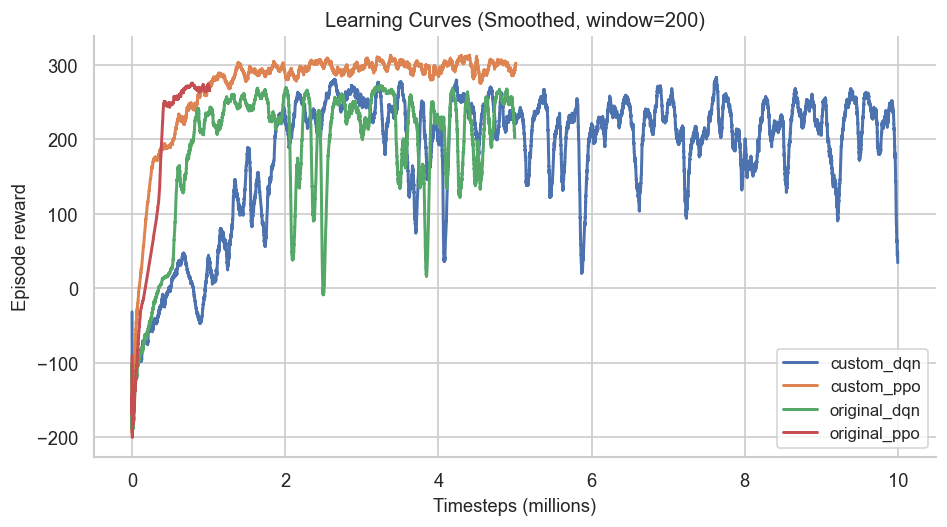

In [47]:
# Learning curves from VecMonitor logs
log_root = RUNS_DIR / "logs"
monitor_files = sorted(log_root.glob("*/monitor.csv"))

if not monitor_files:
    print(f"No monitor.csv files found under {log_root}")
else:
    def load_monitor(path: Path) -> pd.DataFrame:
        df = pd.read_csv(path, comment="#")
        if df.empty:
            return df
        df = df.rename(columns={"r": "reward", "l": "length", "t": "time"})
        df["timesteps"] = df["length"].cumsum()
        df["run"] = path.parent.name
        return df

    runs = []
    for path in monitor_files:
        df = load_monitor(path)
        if not df.empty:
            runs.append(df)

    if not runs:
        print("Monitor files were empty.")
    else:
        data = pd.concat(runs, ignore_index=True)

        window = 200

        data["reward_smooth"] = data.groupby("run")["reward"].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        )

        # FIX: scale timesteps
        data["timesteps_m"] = data["timesteps"] / 1e6

        plt.figure(figsize=(8, 4.5))

        for run_name, group in data.groupby("run"):
            plt.plot(
                group["timesteps_m"],
                group["reward_smooth"],
                label=run_name,
                linewidth=1.8
            )

        plt.title(f"Learning Curves (Smoothed, window={window})")
        plt.xlabel("Timesteps (millions)")
        plt.ylabel("Episode reward")
        plt.legend()
        plt.tight_layout()
        plt.show()

## 13. Conclusion
The custom environment introduces additional constraints and stochasticity, which increases difficulty and variance.
DQN remains competitive across both settings, while PPO is stable and strong in the original environment.
Overall, reward shaping and fuel constraints shift the learned policy toward efficiency and robustness.

## 14. Future work
- Test continuous-control algorithms (SAC, TD3, DDPG).
- Add curriculum learning to improve convergence under random spawn.
- Explore recurrent policies to handle observation noise.
- Study alternative reward shaping strategies and fuel models.
- Apply domain randomization for broader generalization.